<a href="https://colab.research.google.com/github/XTruong1511/TH_DeepLaening/blob/main/TH_Deep_B3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

bài tập về ANN


In [2]:
#install required libraries
!pip install scikeras
import pandas as pd
import numpy as np
#data visualization packages
import matplotlib.pyplot as plt
#keras packages
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from scikeras.wrappers import KerasClassifier
from keras.layers import Dropout
#model evaluation packages
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler

In [3]:
#tải bộ mnist fashion dataset
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion.load_data()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

#reshape data from 3-D to 2-D array
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

#feature scaling
minmax = MinMaxScaler()

X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


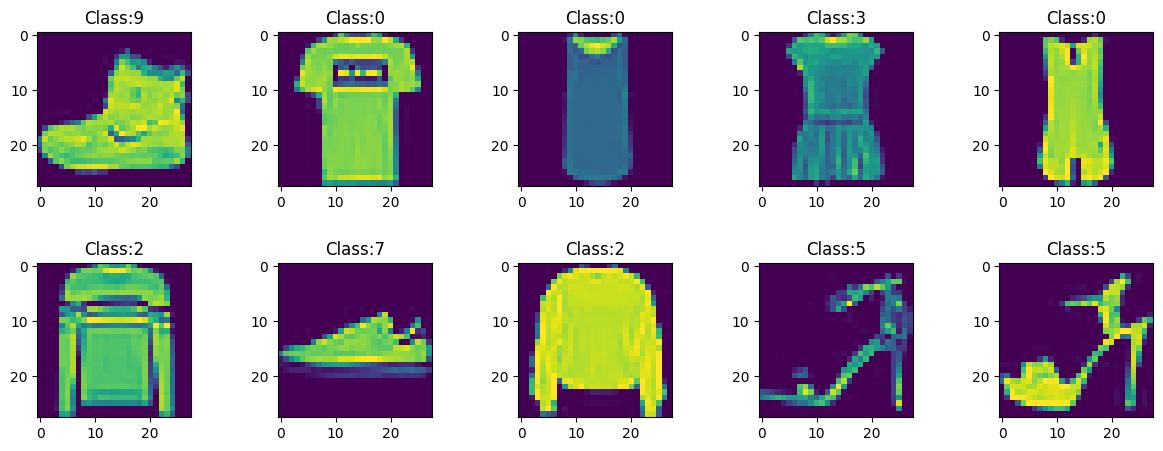

In [4]:
#Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5,figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

In [7]:
#initial ANN model
fashion_model = Sequential()

#add first hidden layer
fashion_model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

#add output layer
fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

#compile neural network
fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#model summary
fashion_model.summary()

# Fit the model and store history in 'model_fit'
model_fit = fashion_model.fit(X_train, y_train, epochs=30, verbose=1, validation_data=(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8242 - loss: 0.4941 - val_accuracy: 0.8485 - val_loss: 0.4205
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8670 - loss: 0.3644 - val_accuracy: 0.8653 - val_loss: 0.3798
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8796 - loss: 0.3288 - val_accuracy: 0.8724 - val_loss: 0.3572
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8872 - loss: 0.3032 - val_accuracy: 0.8661 - val_loss: 0.3778
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8947 - loss: 0.2854 - val_accuracy: 0.8733 - val_loss: 0.3578
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8994 - loss: 0.2711 - val_accuracy: 0.8777 - val_loss: 0.3424
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9034 - loss: 0.2595 - val_accuracy: 0.8795 - val_loss: 0.3375
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9082 - loss: 0

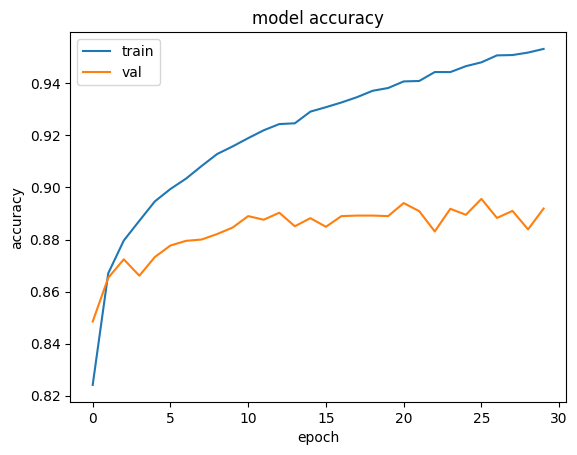

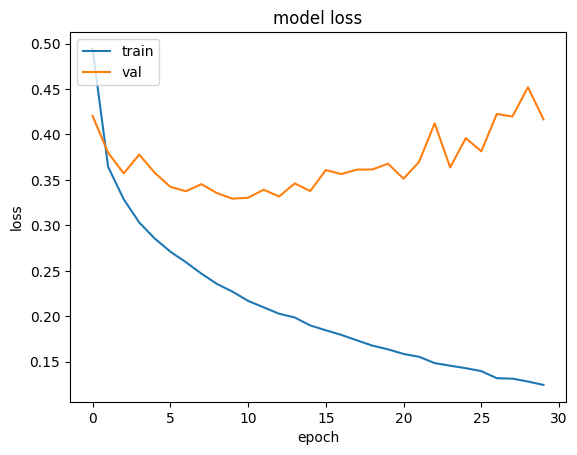

In [8]:
# Biểu đồ Accuracy
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Biểu đồ Loss
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [9]:
print(np.argmax(fashion_model.predict(X_test)[0]), y_test[0])
print(np.argmax(fashion_model.predict(X_test)[10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
4 4


In [11]:
mnist_train_path = '/content/sample_data/mnist_train_small.csv'
mnist_test_path = '/content/sample_data/mnist_test.csv'
mnist_train = pd.read_csv(mnist_train_path)
mnist_test = pd.read_csv(mnist_test_path)
print(mnist_train.head())
print(mnist_train.shape)

X_train = mnist_train.iloc[:,1:]
X_test = mnist_test.iloc[:,1:]
print(X_train.shape)

y_train = mnist_train.iloc[:,0]
y_test = mnist_test.iloc[:,0]

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

   6  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.581  0.582  0.583  \
0  5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
1  7  0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  9  0    0    0    0    0    0    0    0    0  ...      0      0      0   
3  5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  2  0    0    0    0    0    0    0    0    0  ...      0      0      0   

   0.584  0.585  0.586  0.587  0.588  0.589  0.590  
0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0  

[5 rows x 785 columns]
(19999, 785)
(19999, 784)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


In [14]:
import tensorflow as tf
import keras
from keras import Sequential
from keras.layers import Dense

model = Sequential()
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

model_fit = model.fit(X_train, y_train, epochs=30, verbose=1)

print(np.argmax(model.predict(X_test)[0]), y_test[0])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8717 - loss: 1.0987
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9355 - loss: 0.2464
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9463 - loss: 0.2111
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9468 - loss: 0.2322
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9469 - loss: 0.2248
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9524 - loss: 0.2205
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9603 - loss: 0.1885
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9610 - loss: 0.1895
Epoch 9/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9618 - loss: 0.1809
Epoch 10/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9630 - loss: 0.2001
Epoch 11/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9664 - loss: 0.1766
Epoch 12/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

bài tập 1: Viết chương trình cài đặt ANN để nhận dạng ảnh trên bộ dataset CIFAR10 có sẵn trong tensorflow
với các nhãn sau

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)


--- Bắt đầu huấn luyện mô hình ---
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.3273 - loss: 1.8619 - val_accuracy: 0.3723 - val_loss: 1.7532
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.3980 - loss: 1.6758 - val_accuracy: 0.4319 - val_loss: 1.6215
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.4284 - loss: 1.5963 - val_accuracy: 0.4370 - val_loss: 1.5743
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.4473 - loss: 1.5444 - val_accuracy: 0.4629 - val_loss: 1.5187
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.4611 - loss: 1.5053 - val_accuracy: 0.4460 - val_loss: 1.5554
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.4712 - loss: 1.4744 - val_accuracy: 0.4512 - val_loss: 1.5473
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.4815 - loss: 1.4485 - val_accuracy: 0.4752 - val_loss: 1.4797
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━

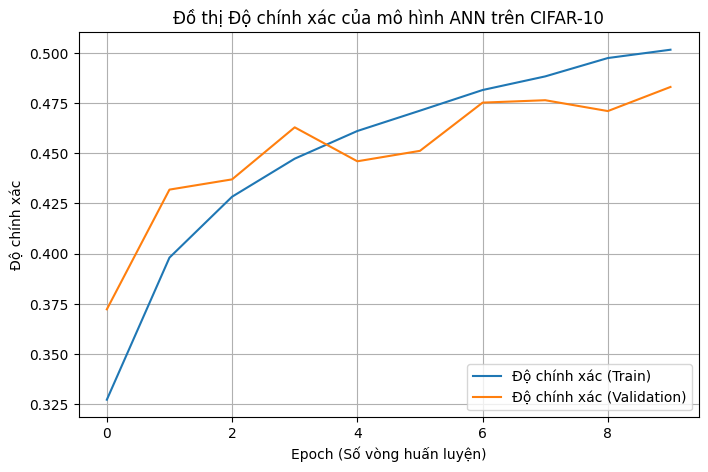

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step

--- Kết quả dự đoán thử ---
Mô hình dự đoán: cat (Nhãn 3)
Nhãn thực tế: cat (Nhãn 3)


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

cifar10 = tf.keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

X_train = X_train / 255.0
X_test = X_test / 255.0

model = models.Sequential()

model.add(layers.Flatten(input_shape=(32, 32, 3)))

# Lớp ẩn 1:
model.add(layers.Dense(512, activation='relu'))

# Lớp ẩn 2:
model.add(layers.Dense(256, activation='relu'))

# Lớp đầu ra:
model.add(layers.Dense(10, activation='softmax'))

model.summary()

# Biên dịch mô hình
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


print("\n--- Bắt đầu huấn luyện mô hình ---")
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

# Đánh giá độ chính xác trên tập Test
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'\nĐộ chính xác trên tập kiểm tra (Test accuracy): {test_acc*100:.2f}%')

# Vẽ biểu đồ thể hiện sự thay đổi của độ chính xác (Accuracy) qua từng epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Độ chính xác (Train)')
plt.plot(history.history['val_accuracy'], label='Độ chính xác (Validation)')
plt.title('Đồ thị Độ chính xác của mô hình ANN trên CIFAR-10')
plt.xlabel('Epoch (Số vòng huấn luyện)')
plt.ylabel('Độ chính xác')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Lấy ảnh đầu tiên trong tập test để dự đoán thử
image_index = 0
prediction = model.predict(np.expand_dims(X_test[image_index], axis=0))
predicted_label = np.argmax(prediction)
true_label = int(y_test[image_index][0])

print(f"\n--- Kết quả dự đoán thử ---")
print(f"Mô hình dự đoán: {class_names[predicted_label]} (Nhãn {predicted_label})")
print(f"Nhãn thực tế: {class_names[true_label]} (Nhãn {true_label})")

bài tập 2. Viết chương trình cài đặt ANN để nhận dạng ảnh chữ viết số trên bộ dataset MNIST do giảng viên
cung cấp với các nhãn sau

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# Danh sách nhãn
class_names = ['Số 0', 'Số 1', 'Số 2', 'Số 3', 'Số 4',
               'Số 5', 'Số 6', 'Số 7', 'Số 8', 'Số 9']

# Tải bộ dataset MNIST
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Chuẩn hóa dữ liệu
X_train = X_train / 255.0
X_test = X_test / 255.0

model = models.Sequential()

# Lớp đầu vào
model.add(layers.Flatten(input_shape=(28, 28)))

# Lớp ẩn
model.add(layers.Dense(128, activation='relu'))

# Lớp đầu ra:
model.add(layers.Dense(10, activation='softmax'))

model.summary()

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("\n--- Bắt đầu quá trình huấn luyện ---")
# Huấn luyện mô hình với 10 vòng
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

# Đánh giá trên tập dữ liệu kiểm tra
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'\nĐộ chính xác của mô hình trên tập Test: {test_acc * 100:.2f}%')

# Dự đoán thử 1 bức ảnh ngẫu nhiên trong tập Test
image_index = 0
# Mở rộng chiều
predictions = model.predict(np.expand_dims(X_test[image_index], axis=0))
predicted_label_index = np.argmax(predictions)
true_label_index = y_test[image_index]

print("\n--- KẾT QUẢ DỰ ĐOÁN THỬ ---")
print(f"Mô hình dự đoán: {class_names[predicted_label_index]}")
print(f"Nhãn thực tế: {class_names[true_label_index]}")

# (Tùy chọn) Hiển thị bức ảnh đó ra màn hình để kiểm chứng
plt.imshow(X_test[image_index], cmap=plt.cm.binary)
plt.title(f"Dự đoán: {class_names[predicted_label_index]} - Thực tế: {class_names[true_label_index]}")
plt.axis('off')
plt.show()

bài tập 3. Cho đoạn mã đọc ảnh của Cat và Dog. Hãy viết chương trình cài đặt ANN để nhận dạng ảnh Cat hoặc Dog. Dữ liệu do giảng viên cung cấp

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

print("Đang tải và xử lý dữ liệu Cats & Dogs từ TFDS ...")

target_size = (200, 200)


(ds_train, ds_test), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)


def preprocess(image, label):
    image = tf.image.resize(image, target_size)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

ds_train = ds_train.map(preprocess)
ds_test = ds_test.map(preprocess)

def ds_to_numpy_batched(dataset, batch_size=32):
    images_list = []
    labels_list = []
    for images_batch, labels_batch in dataset.batch(batch_size).as_numpy_iterator():
        images_list.append(images_batch)
        labels_list.append(labels_batch)
    return np.concatenate(images_list, axis=0), np.concatenate(labels_list, axis=0)

X_train, y_train = ds_to_numpy_batched(ds_train)
X_test, y_test = ds_to_numpy_batched(ds_test)

print("Xử lý xong!")

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

model = models.Sequential()

# Lớp đầu vào
model.add(layers.Flatten(input_shape=(target_size[0], target_size[1], 3)))

# Lớp ẩn 1
model.add(layers.Dense(128, activation='relu'))

# Lớp ẩn 2
model.add(layers.Dense(64, activation='relu'))

# Lớp đầu ra
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("\n--- Bắt đầu huấn luyện mô hình ---")
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nĐộ chính xác trên tập kiểm tra: {test_acc*100:.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Đồ thị Accuracy - Dogs vs Cats')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

idx = 0
prediction = model.predict(np.expand_dims(X_test[idx], axis=0))[0][0]

predicted_label = "Dog" if prediction >= 0.5 else "Cat"
true_label = "Dog" if y_test[idx] == 1.0 else "Cat"

print(f"\nẢnh thử nghiệm dự đoán là: {predicted_label} (Thực tế: {true_label})")

plt.imshow(X_test[idx])
plt.title(f"Dự đoán: {predicted_label} | Thực tế: {true_label}")
plt.axis('off')
plt.show()


4. Viết chương trình cài đặt ANN để dự báo thu nhập một người > 50K/năm hay <= 50K/năm (nhãn cuối) theo bộ dữ liệu adult do giảng viên cung cấp

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt

print("Đang tải dữ liệu Adult Income ...")

# Khai báo đường dẫn trực tiếp tới file dữ liệu
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Đọc dữ liệu từ URL
df = pd.read_csv(url, names=columns, skipinitialspace=True)

print(f"Đã tải thành công! Kích thước dữ liệu gốc: {df.shape}")

# Xóa các dòng chứa giá trị rỗng
df = df.replace('?', np.nan).dropna()

# Tách đặc trưng (X) và Nhãn dự đoán (y)
X = df.drop('income', axis=1)
y = df['income']

# 1.1 Xử lý Nhãn (y): Chuyển '<=50K' thành 0 và '>50K' thành 1
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

print(f"Bản đồ nhãn: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

# 1.2 Xử lý Đặc trưng (X): Chuyển đổi các cột phân loại (chữ) thành các cột số
X = pd.get_dummies(X, drop_first=True)

# 1.3 Chia tập dữ liệu: 80% để huấn luyện, 20% để kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1.4 Chuẩn hóa các thang đo số
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Kích thước tập X_train sau xử lý: {X_train.shape}")

model = models.Sequential()

# Lớp ẩn 1
model.add(layers.Dense(64, activation='relu', input_dim=X_train.shape[1]))

# Lớp ẩn 2
model.add(layers.Dense(32, activation='relu'))

# Lớp đầu ra
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("\n--- Bắt đầu huấn luyện mô hình ---")
# Huấn luyện mô hình
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)


test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nĐộ chính xác của mô hình trên tập Test: {test_acc * 100:.2f}%")

# Vẽ đồ thị độ chính xác
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Độ chính xác (Train)')
plt.plot(history.history['val_accuracy'], label='Độ chính xác (Validation)')
plt.title('Quá trình huấn luyện mô hình dự báo thu nhập Adult')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

5. Viết chương trình cài đặt ANN để dự báo việc đánh giá chất lượng xe ô tô (nhãn cuối) từ bộ dữ liệu car do giảng viên cung cấp.

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
print("Đang tải dữ liệu Car Evaluation...")


url = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"
columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df = pd.read_csv(url, names=columns)

print(f"Kích thước dữ liệu gốc: {df.shape}")

# Tách đặc trưng (X) và Nhãn dự đoán (y)
X = df.drop('class', axis=1)
y = df['class']

# 1.1 Xử lý Nhãn (y)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
class_names = label_encoder.classes_
print(f"Bản đồ nhãn phân loại: {dict(enumerate(class_names))}")

# 1.2 Xử lý Đặc trưng (X)
X = pd.get_dummies(X)

# 1.3 Chia tập dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ép kiểu dữ liệu về float32 để TensorFlow xử lý mượt mà hơn
X_train = np.asarray(X_train).astype(np.float32)
X_test = np.asarray(X_test).astype(np.float32)

print(f"Số lượng đặc trưng (input_dim) sau khi biến đổi: {X_train.shape[1]}")


model = models.Sequential()

# Lớp ẩn 1
model.add(layers.Dense(64, activation='relu', input_dim=X_train.shape[1]))

# Lớp ẩn 2
model.add(layers.Dense(32, activation='relu'))

# Lớp đầu ra
model.add(layers.Dense(4, activation='softmax'))

model.summary()

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("\n--- Bắt đầu huấn luyện mô hình ---")
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.1, verbose=1)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nĐộ chính xác của mô hình trên tập Test: {test_acc * 100:.2f}%")

# Vẽ đồ thị độ chính xác
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Đồ thị quá trình huấn luyện - Car Evaluation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


sample_idx = 10
sample = X_test[sample_idx].reshape(1, -1)

# Mô hình sẽ trả về 1 mảng 4 giá trị xác suất tương ứng với 4 nhãn
predictions = model.predict(sample)
predicted_label_idx = np.argmax(predictions)
true_label_idx = y_test[sample_idx]

print(f"\n--- KẾT QUẢ DỰ ĐOÁN ---")
print(f"Xác suất cho 4 lớp: {predictions[0]}")
print(f"Mô hình dự đoán chất lượng xe là: {class_names[predicted_label_idx]}")
print(f"Chất lượng thực tế của xe là: {class_names[true_label_idx]}")